# 波头 CNN：Apple M5 / PyTorch MPS 两阶段迁移训练

本 Notebook 使用现有 `wavefront_dataset_v1` 完成环境检查、数据审计、预处理可视化、Residual U-Net 搭建、MPS 前向/反向自检、hard+soft 预训练、hard-only 精调、验证测试和结果导出。

**关键边界**：波头网络只输入单相波形，不输入线路长度；训练/验证/测试严格沿用 `split_event`，防止同一事件泄漏。

## 1. 环境与项目路径

In [ ]:
from pathlib import Path
import json
import platform
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

project_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    path for path in project_candidates
    if (path / 'data/derived/wavefront_dataset_v1/waveforms.h5').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from machine_learning.wavefront_cnn.wavefront_training.config import TrainingConfig
from machine_learning.wavefront_cnn.wavefront_training.data import (
    WavefrontDataset, build_phase_index, create_dataloaders
)
from machine_learning.wavefront_cnn.wavefront_training.engine import (
    evaluate_model, load_checkpoint, resolve_device, train_one_epoch
)
from machine_learning.wavefront_cnn.wavefront_training.evaluate import evaluate_checkpoint
from machine_learning.wavefront_cnn.wavefront_training.export_onnx import export_checkpoint
from machine_learning.wavefront_cnn.wavefront_training.losses import WavefrontLoss
from machine_learning.wavefront_cnn.wavefront_training.model import WavefrontResUNet
from machine_learning.wavefront_cnn.wavefront_training.train import run_transfer_training

print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT)
print('MPS built:', torch.backends.mps.is_built())
print('MPS available:', torch.backends.mps.is_available())
assert torch.backends.mps.is_available(), '当前 kernel 无法使用 MPS，请切换到 m5 kernel。'

Python: 3.12.13
PyTorch: 2.12.0
Platform: macOS-26.5.1-arm64-arm-64bit
Project root: /Users/shaorouzongdu/程序/FaultLocation_demo
MPS built: True
MPS available: True


## 2. 训练配置

默认只运行 MPS 烟雾检查，不启动长训练。确认前面所有检查通过后，将 `RUN_FULL_TRAINING` 改为 `True`。准确率优先，因此默认使用 FP32，不开启 MPS AMP。

In [ ]:
DATASET_DIR = PROJECT_ROOT / 'data/derived/wavefront_dataset_v1'
OUTPUT_DIR = PROJECT_ROOT / 'data/derived/wavefront_cnn_run'
RUN_MPS_SMOKE = True
RUN_FULL_TRAINING = False
RUN_FINAL_EVALUATION = False
RUN_ONNX_EXPORT = False

config = TrainingConfig(
    dataset_dir=str(DATASET_DIR),
    output_dir=str(OUTPUT_DIR),
    device='mps',
    seed=42,
    base_channels=32,
    bottleneck_dilations=(1, 2, 4, 8),
    batch_size=32,
    num_workers=0,
    heatmap_sigma=6.0,
    pretrain_epochs=40,
    finetune_epochs=60,
    freeze_epochs=5,
    pretrain_lr=2e-3,
    finetune_lr=5e-4,
    weight_decay=1e-4,
    patience=10,
    amp=False,
)
display(pd.Series(config.to_dict(), name='value').to_frame())

,value
dataset_dir,/Users/shaorouzongdu/程序/FaultLocation_demo/dat...
output_dir,/Users/shaorouzongdu/程序/FaultLocation_demo/dat...
device,mps
seed,42
base_channels,32
bottleneck_dilations,"[1, 2, 4, 8]"
batch_size,32
num_workers,0
heatmap_sigma,6.0
pretrain_epochs,40


## 3. 数据审计与事件泄漏检查

In [ ]:
labels = pd.read_csv(DATASET_DIR / 'phase_labels.csv')
manifest = pd.read_csv(DATASET_DIR / 'manifest.csv')
with h5py.File(DATASET_DIR / 'waveforms.h5', 'r') as handle:
    signal_shape = handle['signals'].shape
    sampling_rate_hz = float(handle.attrs['target_sampling_rate_hz'])
    window_samples = int(handle.attrs['window_samples'])

valid_labels = labels[labels.window_wavefront_index >= 0].copy()
event_split_counts = manifest.groupby('event_key').split_event.nunique()
leaking_events = int((event_split_counts > 1).sum())
audit = {
    'hdf5_shape': signal_shape,
    'sampling_rate_hz': sampling_rate_hz,
    'window_samples': window_samples,
    'valid_hard': int((valid_labels.label_status == 'hard').sum()),
    'valid_soft': int((valid_labels.label_status == 'soft').sum()),
    'valid_review': int((valid_labels.label_status == 'review').sum()),
    'leaking_events': leaking_events,
}
print(json.dumps(audit, ensure_ascii=False, indent=2))
display(pd.crosstab(valid_labels.label_status, valid_labels.split_event, margins=True))
assert signal_shape == (2587, 3, 8192)
assert leaking_events == 0
assert audit['valid_hard'] == 4592

{
  "hdf5_shape": [
    2587,
    3,
    8192
  ],
  "sampling_rate_hz": 1250000.0,
  "window_samples": 8192,
  "valid_hard": 4592,
  "valid_soft": 1306,
  "valid_review": 205,
  "leaking_events": 0
}


split_event,test,train,val,All
label_status,,,,
hard,543,3630,419,4592
review,16,165,24,205
soft,129,1086,91,1306
All,688,4881,534,6103


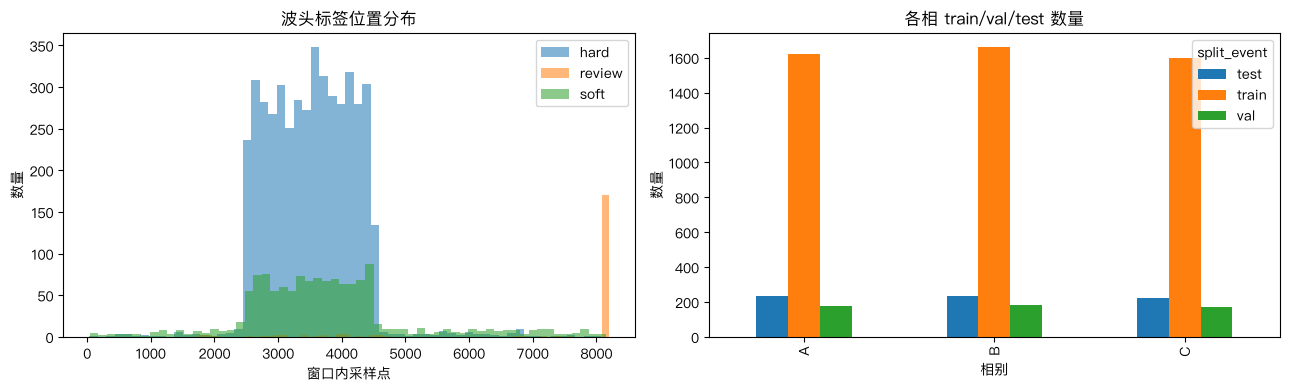

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for status, group in valid_labels.groupby('label_status'):
    axes[0].hist(group.window_wavefront_index, bins=60, alpha=0.55, label=status)
axes[0].set(title='波头标签位置分布', xlabel='窗口内采样点', ylabel='数量')
axes[0].legend()
pd.crosstab(valid_labels.phase, valid_labels.split_event).plot.bar(ax=axes[1])
axes[1].set(title='各相 train/val/test 数量', xlabel='相别', ylabel='数量')
plt.tight_layout()
plt.show()

## 4. 预处理与监督热图

训练阶段按相读取 HDF5，执行同步时间平移、幅值变化、极性翻转、噪声与基线漂移。验证和测试不做随机增强。hard 权重为 1.0，soft 权重为 0.5。

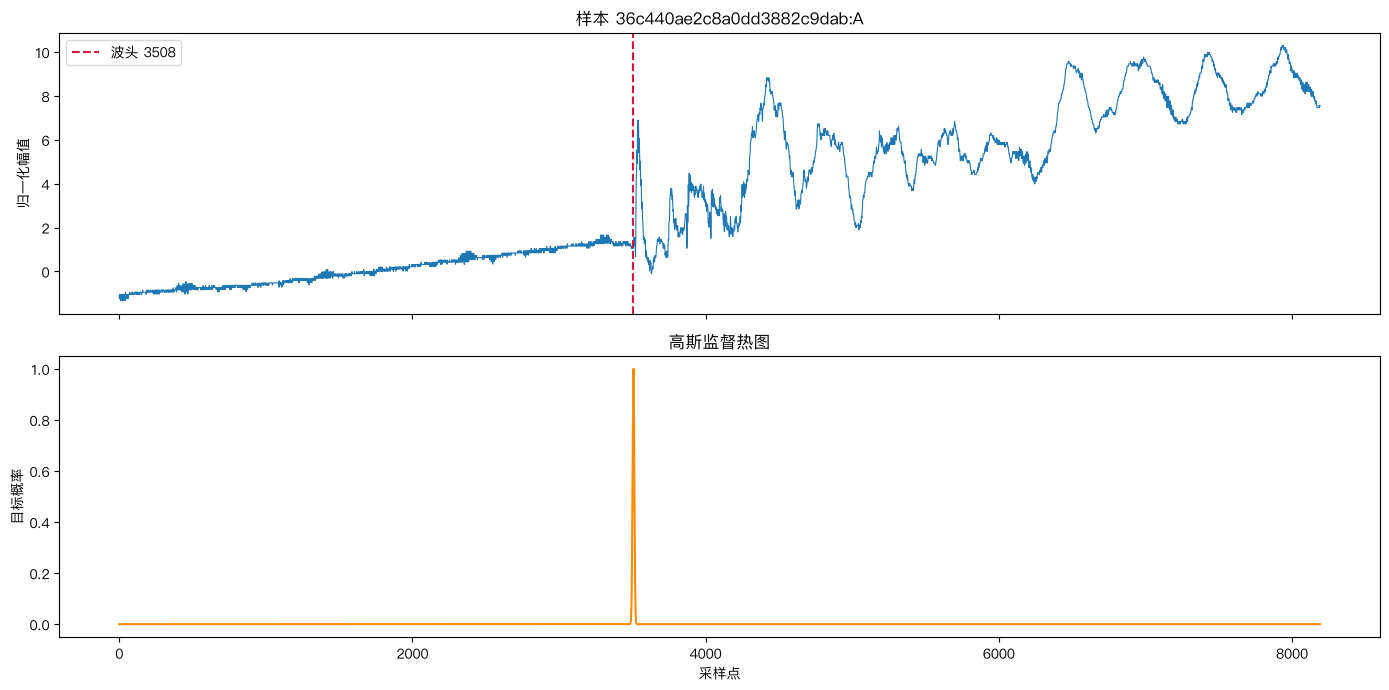

In [ ]:
hard_train_index = build_phase_index(
    DATASET_DIR / 'phase_labels.csv', split='train', statuses=('hard',)
)
preview_dataset = WavefrontDataset(
    DATASET_DIR / 'waveforms.h5', hard_train_index, augment=False, heatmap_sigma=6.0
)
preview = preview_dataset[0]
waveform = preview['signal'].squeeze().numpy()
heatmap = preview['target'].squeeze().numpy()
coordinate = float(preview['coordinate'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(waveform, linewidth=0.8)
axes[0].axvline(coordinate, color='crimson', linestyle='--', label=f'波头 {coordinate:.0f}')
axes[0].set(title=f"样本 {preview['sample_id']}", ylabel='归一化幅值')
axes[0].legend()
axes[1].plot(heatmap, color='darkorange')
axes[1].set(title='高斯监督热图', xlabel='采样点', ylabel='目标概率')
plt.tight_layout()
plt.show()

## 5. Residual U-Net 与 M5 GPU 自检

网络输出与输入等长的 8192 点 logits。空洞卷积捕获多尺度行波上下文，U-Net 跳接保留波头局部细节。以下单元只训练一个真实批次，用于确认 MPS 前向、反向和优化器链路。

In [ ]:
device = resolve_device('mps')
model = WavefrontResUNet(base_channels=32, bottleneck_dilations=(1, 2, 4, 8)).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'模型参数: {parameter_count:,}; 可训练参数: {trainable_count:,}; device={device}')

if RUN_MPS_SMOKE:
    smoke_loaders = create_dataloaders(
        DATASET_DIR, statuses=('hard', 'soft'), batch_size=4, num_workers=0,
        heatmap_sigma=6.0, seed=42
    )
    smoke_batch = next(iter(smoke_loaders['train']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    smoke_metrics = train_one_epoch(
        model, [smoke_batch], WavefrontLoss(), optimizer, device=device, scaler=None,
        sampling_rate_hz=sampling_rate_hz, amp=False, max_batches=1
    )
    print('MPS 单批次反向传播通过：')
    print(json.dumps(smoke_metrics, ensure_ascii=False, indent=2))
    del smoke_loaders, smoke_batch, optimizer
    torch.mps.empty_cache()

模型参数: 2,420,193; 可训练参数: 2,420,193; device=mps


MPS 单批次反向传播通过：
{
  "count": 4,
  "mae_samples": 2532.894775390625,
  "rmse_samples": 2904.314453125,
  "p95_samples": 4281.0,
  "mae_us": 2026.3158203125,
  "p95_us": 3424.8,
  "within_1_samples": 0.0,
  "within_2_samples": 0.0,
  "within_4_samples": 0.0,
  "within_8_samples": 0.0,
  "within_16_samples": 0.0,
  "loss": 1.2700488567352295
}


## 6. 两阶段迁移训练

1. **预训练**：hard+soft，学习不同线路、故障和噪声条件下的通用波头形态。
2. **精调**：载入最佳预训练权重，前 5 个 epoch 冻结浅层编码器，之后全部解冻，只使用 hard 标签。
3. 最佳模型按验证集 MAE 保存，早停耐心为 10 个 epoch。

In [ ]:
if True:
    training_report = run_transfer_training(config)
else:
    print('完整训练未启动。检查以上输出后，将 RUN_FULL_TRAINING 改为 True 并重新运行本单元。')

## 7. 训练曲线与测试结果

In [ ]:
history_files = [OUTPUT_DIR / 'history_pretrain.csv', OUTPUT_DIR / 'history_finetune.csv']
available_history = [path for path in history_files if path.exists()]
if available_history:
    history = pd.concat([pd.read_csv(path) for path in available_history], ignore_index=True)
    display(history.tail(10))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for stage, group in history.groupby('stage'):
        axes[0].plot(group.epoch, group.train_loss, label=f'{stage} train')
        axes[0].plot(group.epoch, group.val_loss, '--', label=f'{stage} val')
        axes[1].plot(group.epoch, group.val_mae_samples, label=stage)
    axes[0].set(title='训练与验证损失', xlabel='epoch', ylabel='loss')
    axes[1].set(title='验证集波头 MAE', xlabel='epoch', ylabel='采样点')
    axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()
else:
    print('尚无训练历史。完成第 6 节训练后再运行本单元。')

metrics_path = OUTPUT_DIR / 'test_metrics.json'
if metrics_path.exists():
    display(pd.Series(json.loads(metrics_path.read_text())['test_metrics'], name='test').to_frame())

尚无训练历史。完成第 6 节训练后再运行本单元。


In [9]:
best_checkpoint = OUTPUT_DIR / 'best_finetune.pt'
if RUN_FINAL_EVALUATION:
    assert best_checkpoint.exists(), '先完成完整训练。'
    final_metrics = evaluate_checkpoint(
        best_checkpoint, DATASET_DIR, split='test', device_name='mps',
        output_dir=OUTPUT_DIR / 'evaluation'
    )
    print(json.dumps(final_metrics, ensure_ascii=False, indent=2))
else:
    print('独立最终评估未启动；需要时设置 RUN_FINAL_EVALUATION=True。')

独立最终评估未启动；需要时设置 RUN_FINAL_EVALUATION=True。


## 8. 模型导出

`.pt` 是后续 Python 推理和继续训练的主模型。ONNX 仅作为跨平台部署备选，不影响 M5 训练。

In [10]:
if RUN_ONNX_EXPORT:
    assert best_checkpoint.exists(), '先完成完整训练。'
    export_report = export_checkpoint(best_checkpoint, OUTPUT_DIR / 'wavefront_resunet.onnx')
    print(json.dumps(export_report, ensure_ascii=False, indent=2))
else:
    print('ONNX 导出未启动；需要时设置 RUN_ONNX_EXPORT=True。')

ONNX 导出未启动；需要时设置 RUN_ONNX_EXPORT=True。


## 9. 判定标准与下一步

优先查看 `mae_samples`、`p95_samples` 和 `within_4_samples`。在 1.25 MHz 下，每个采样点为 0.8 μs。只有在独立测试集达到稳定误差后，才应把 CNN 波头坐标接入双端故障定位；线路长度继续由拓扑层提供。